# 01 — Data and Segments

Builds the product-evaluation lens for the recommender project: user activity segments and restaurant popularity tiers. The real Yelp Open Dataset is not committed; this notebook reads the local processed Parquet files created by `make data`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..", "src").resolve()))

import json
import matplotlib.pyplot as plt
import pandas as pd

from recsys.build_data import BUSINESS_PARQUET, REVIEWS_ALL_PARQUET, REVIEWS_CLEAN_PARQUET
from recsys.engine import build_connection

ROOT = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
FIGURES = ROOT / "reports" / "figures"
OUTPUTS.mkdir(exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

reviews_all = pd.read_parquet(REVIEWS_ALL_PARQUET)
reviews_clean = pd.read_parquet(REVIEWS_CLEAN_PARQUET)
business = pd.read_parquet(BUSINESS_PARQUET)
con = build_connection()
print(f"Raw scoped reviews: {len(reviews_all):,}")
print(f"Clean modeling reviews: {len(reviews_clean):,}")
print(f"Restaurants: {len(business):,}")


Raw scoped reviews: 1,100,250
Clean modeling reviews: 398,432
Restaurants: 12,641


## User Activity Segments

`new` users have 1-2 reviews, `casual` users have 3-9, and `power` users have 10 or more. This split is important because collaborative recommenders need interaction history; the product cannot assume new users have enough signal.

In [2]:
user_segments = con.sql("SELECT * FROM user_segment_summary").df()
user_segments


,user_segment,n_users,total_reviews,pct_of_users,pct_of_review_volume
0,new,229765,280364.0,73.54,25.48
1,casual,63862,294987.0,20.44,26.81
2,power,18800,524899.0,6.02,47.71


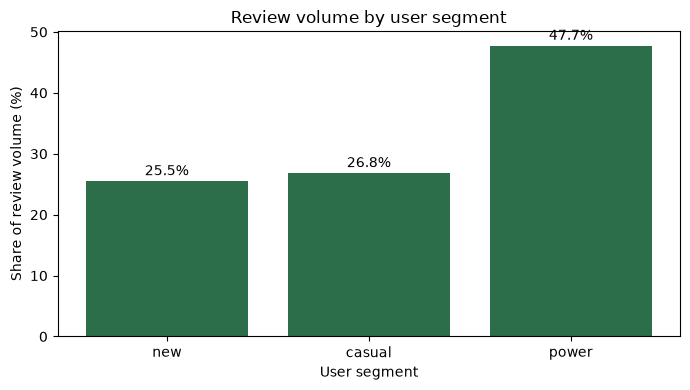

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(user_segments["user_segment"], user_segments["pct_of_review_volume"], color="#2C6E49")
ax.set_title("Review volume by user segment")
ax.set_xlabel("User segment")
ax.set_ylabel("Share of review volume (%)")
for i, row in user_segments.iterrows():
    ax.text(i, row["pct_of_review_volume"] + 1, f"{row['pct_of_review_volume']:.1f}%", ha="center")
fig.tight_layout()
fig.savefig(FIGURES / "user_segment_volume.png", dpi=160)
plt.show()


## Restaurant Popularity Tiers

Restaurants are grouped by review count: low (<20), medium (20-99), and high (100+). This lets the evaluation reveal whether a model performs only on already-popular restaurants.

In [4]:
restaurant_segments = con.sql("SELECT * FROM restaurant_segment_summary").df()
restaurant_segments


,popularity_tier,n_restaurants,avg_stars,avg_review_count
0,low,4347,3.37,10.7
1,medium,5528,3.52,47.2
2,high,2766,3.76,272.5


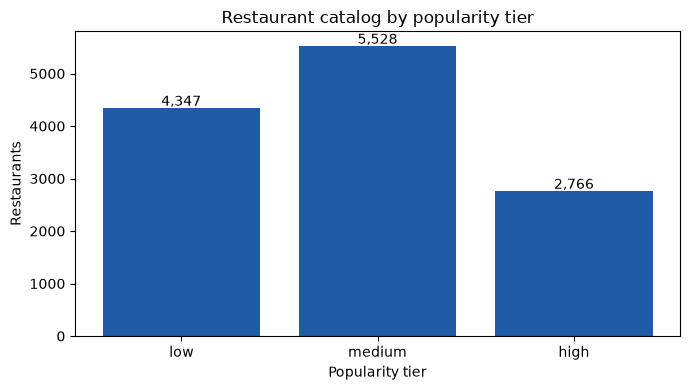

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(restaurant_segments["popularity_tier"], restaurant_segments["n_restaurants"], color="#1F5AA6")
ax.set_title("Restaurant catalog by popularity tier")
ax.set_xlabel("Popularity tier")
ax.set_ylabel("Restaurants")
for i, row in restaurant_segments.iterrows():
    ax.text(i, row["n_restaurants"] + 40, f"{row['n_restaurants']:,}", ha="center")
fig.tight_layout()
fig.savefig(FIGURES / "restaurant_popularity_tiers.png", dpi=160)
plt.show()


In [6]:
summary = {
    "scoped_reviews": int(len(reviews_all)),
    "scoped_users": int(reviews_all["user_id"].nunique()),
    "scoped_restaurants": int(business["business_id"].nunique()),
    "clean_reviews": int(len(reviews_clean)),
    "clean_users": int(reviews_clean["user_id"].nunique()),
    "clean_restaurants": int(reviews_clean["business_id"].nunique()),
}
user_segments.to_csv(OUTPUTS / "user_segment_summary.csv", index=False)
restaurant_segments.to_csv(OUTPUTS / "restaurant_segment_summary.csv", index=False)
(OUTPUTS / "data_summary.json").write_text(json.dumps(summary, indent=2))
summary


{'scoped_reviews': 1100250,
 'scoped_users': 312427,
 'scoped_restaurants': 12641,
 'clean_reviews': 398432,
 'clean_users': 29440,
 'clean_restaurants': 9061}